# 📊 Analisi Esplorativa dei Dati (EDA)

In questo notebook analizziamo il dataset pulito per comprendere:
- la distribuzione dei prezzi
- la distribuzione della durata dei voli
- le compagnie aeree più frequenti
- le rotte più costose
- l'andamento dei prezzi per mese, giorno e stagione

I grafici verranno salvati automaticamente nella cartella:
`outputs/figures/`

In [1]:
import sys #È un modulo che permette di interagire con il sistema Python 
           #Guarda anche in altre cartelle quando cerchi i moduli
import os  #lo usiamo per ottenere il percorso della cartella superiore

# Aggiunge la cartella principale del progetto al percorso dei moduli
# prende la cartella superiore rispetto al notebook.
sys.path.append(os.path.abspath(".."))

In [2]:
# 📦 Importazione librerie
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


print("✔️ Librerie importate correttamente.")

✔️ Librerie importate correttamente.


## 📥 Caricamento del dataset pulito
Il file deve essere già stato generato dal notebook precedente.

In [3]:
df = pd.read_parquet("../data/processed/data_clean.parquet")
print("Dataset pulito caricato correttamente.")
df.head()

Dataset pulito caricato correttamente.


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_Month,Day_of_Week,Is_Weekend,Season,Duration_min
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,1900-01-01 22:20:00,NaT,2h 50m,0,no info,3897,3,Sunday,1,Spring,170
1,Air India,2019-01-05,Kolkata,Banglore,CCU → IXR → BBI → BLR,1900-01-01 05:50:00,1900-01-01 13:15:00,7h 25m,2,no info,7662,1,Saturday,1,Winter,445
2,Jet Airways,2019-09-06,Delhi,Cochin,DEL → LKO → BOM → COK,1900-01-01 09:25:00,NaT,19h,2,no info,13882,9,Friday,0,Autumn,1140
3,IndiGo,2019-12-05,Kolkata,Banglore,CCU → NAG → BLR,1900-01-01 18:05:00,1900-01-01 23:30:00,5h 25m,1,no info,6218,12,Thursday,0,Winter,325
4,IndiGo,2019-01-03,Banglore,New Delhi,BLR → NAG → DEL,1900-01-01 16:50:00,1900-01-01 21:35:00,4h 45m,1,no info,13302,1,Thursday,0,Winter,285


In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 10462 entries, 0 to 10682
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Airline          10462 non-null  str           
 1   Date_of_Journey  10462 non-null  datetime64[us]
 2   Source           10462 non-null  str           
 3   Destination      10462 non-null  str           
 4   Route            10462 non-null  str           
 5   Dep_Time         10462 non-null  datetime64[us]
 6   Arrival_Time     6320 non-null   datetime64[us]
 7   Duration         10462 non-null  str           
 8   Total_Stops      10462 non-null  int64         
 9   Additional_Info  10462 non-null  str           
 10  Price            10462 non-null  int64         
 11  Journey_Month    10462 non-null  int32         
 12  Day_of_Week      10462 non-null  str           
 13  Is_Weekend       10462 non-null  int64         
 14  Season           10462 non-null  str           
 15  D

## 📊 Distribuzione dei prezzi dei voli

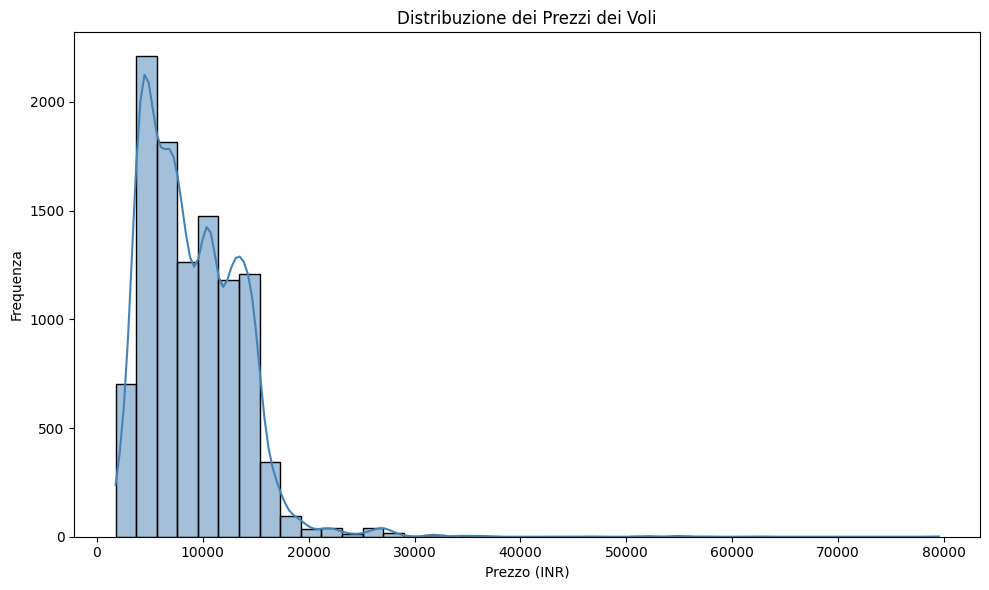

In [5]:
plt.figure(figsize=(10,6))
sns.histplot(df['Price'], bins=40, kde=True, color='steelblue')
plt.title('Distribuzione dei Prezzi dei Voli')
plt.xlabel('Prezzo (INR)')
plt.ylabel('Frequenza')
plt.tight_layout()
plt.savefig('../outputs/figures/distribuzione_prezzi.png')
plt.show()

## ✈️ Numero di voli per compagnia aerea

C:\Users\Utente\AppData\Local\Temp\ipykernel_5340\1027707427.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


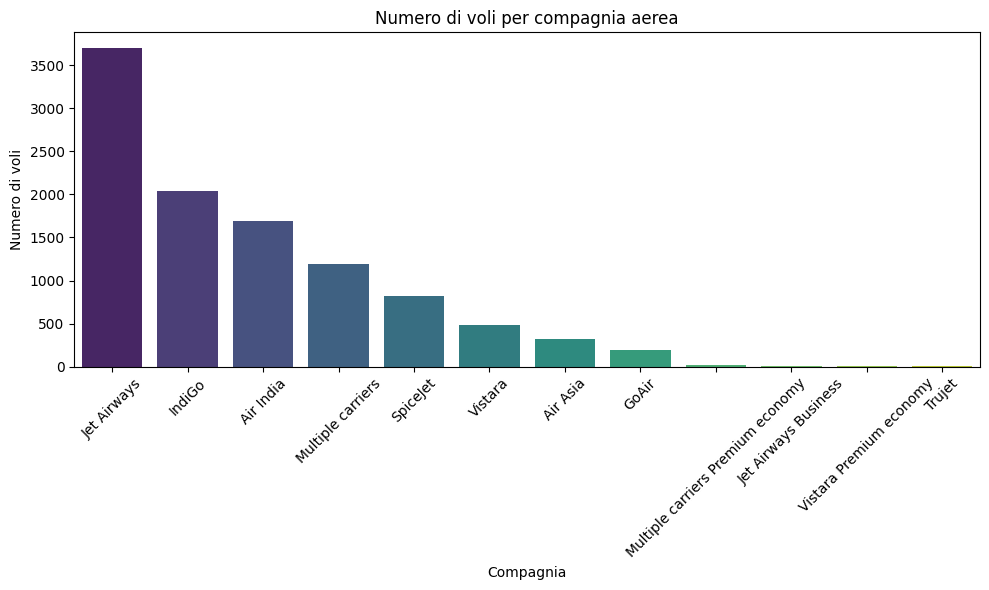

In [6]:
# Conteggio dei voli per compagnia
conteggi = df['Airline'].value_counts()

# Grafico
plt.figure(figsize=(10, 6))
sns.barplot(
    x=conteggi.index,
    y=conteggi.values,
    palette="viridis",
    legend=False   # evita il FutureWarning di Seaborn 0.14
)
plt.title("Numero di voli per compagnia aerea")
plt.xlabel("Compagnia")
plt.ylabel("Numero di voli")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## ⏱️ Distribuzione della durata dei voli (in minuti)

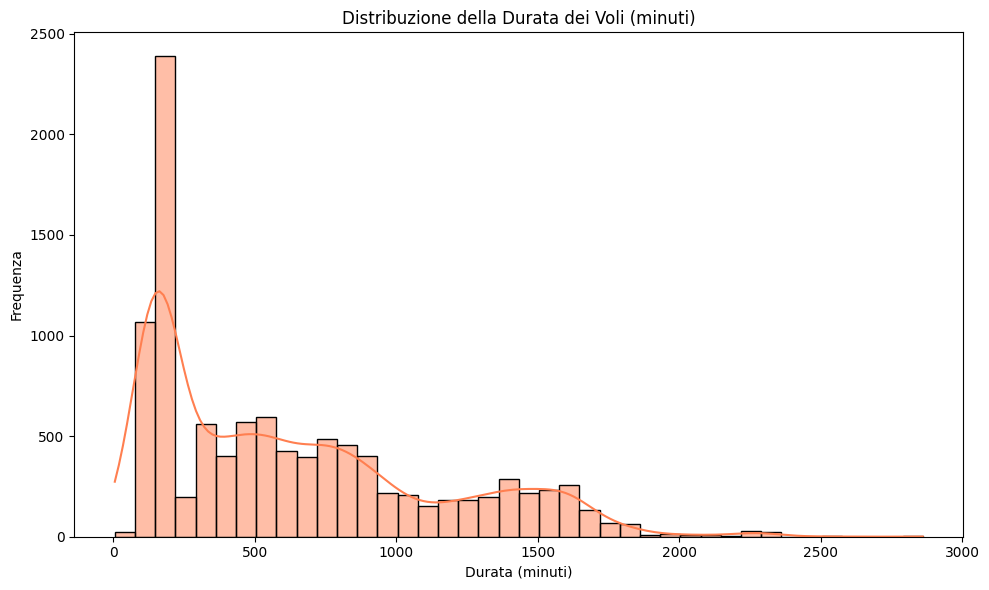

In [7]:
plt.figure(figsize=(10,6))
sns.histplot(df['Duration_min'], bins=40, kde=True, color='coral')
plt.title('Distribuzione della Durata dei Voli (minuti)')
plt.xlabel('Durata (minuti)')
plt.ylabel('Frequenza')
plt.tight_layout()
plt.savefig('../outputs/figures/distribuzione_durata.png')
plt.show()

## 💰 Prezzo medio per compagnia aerea

C:\Users\Utente\AppData\Local\Temp\ipykernel_5340\2662996001.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


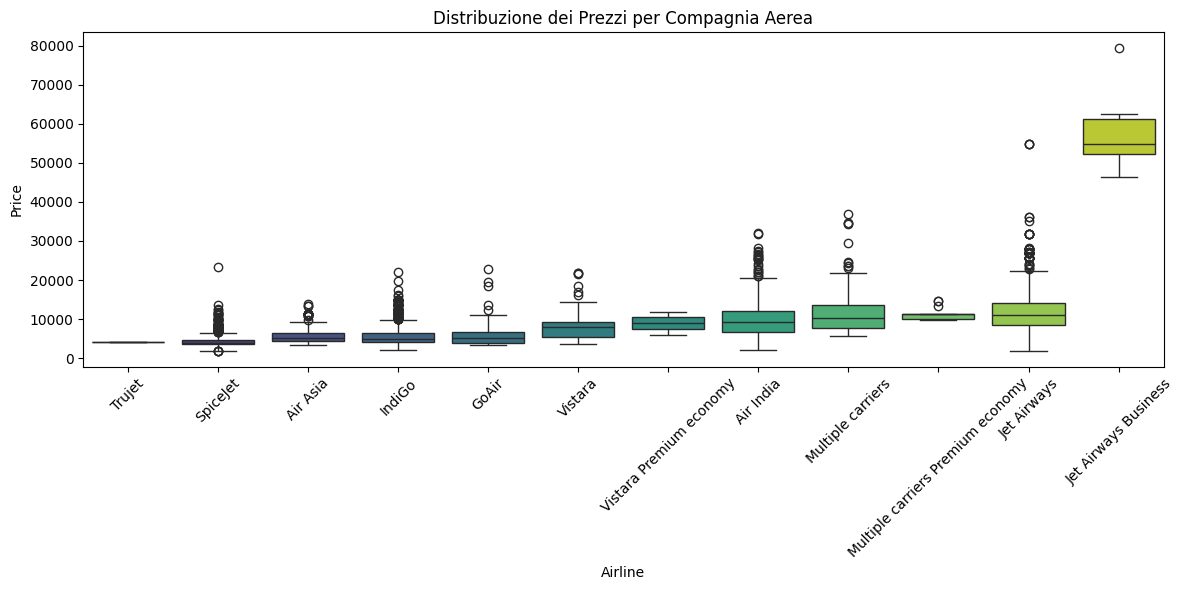

In [8]:
plt.figure(figsize=(12,6))
ordine = df.groupby('Airline')['Price'].mean().sort_values().index
sns.boxplot(
    data=df,
    x='Airline',
    y='Price',
    order=ordine,
    palette='viridis',
    legend=False
)
plt.xticks(rotation=45)
plt.title('Distribuzione dei Prezzi per Compagnia Aerea')
plt.tight_layout()
plt.savefig('../outputs/figures/prezzi_per_compagnia.png')
plt.show()

## 🌍 Rotte più costose (Top 5-6)

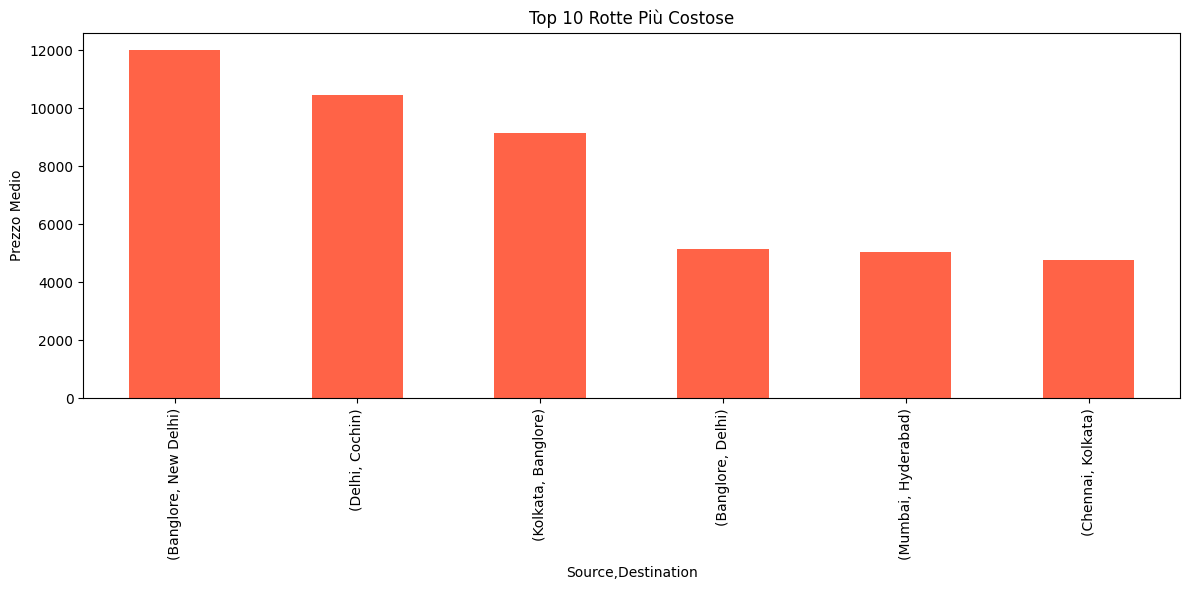

In [9]:
rotte = df.groupby(['Source','Destination'])['Price'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
rotte.plot(kind='bar', color='tomato')
plt.title('Top 10 Rotte Più Costose')
plt.ylabel('Prezzo Medio')
plt.tight_layout()
plt.savefig('../outputs/figures/rotte_costose.png')
plt.show()

## 📅 Prezzo medio per mese del viaggio

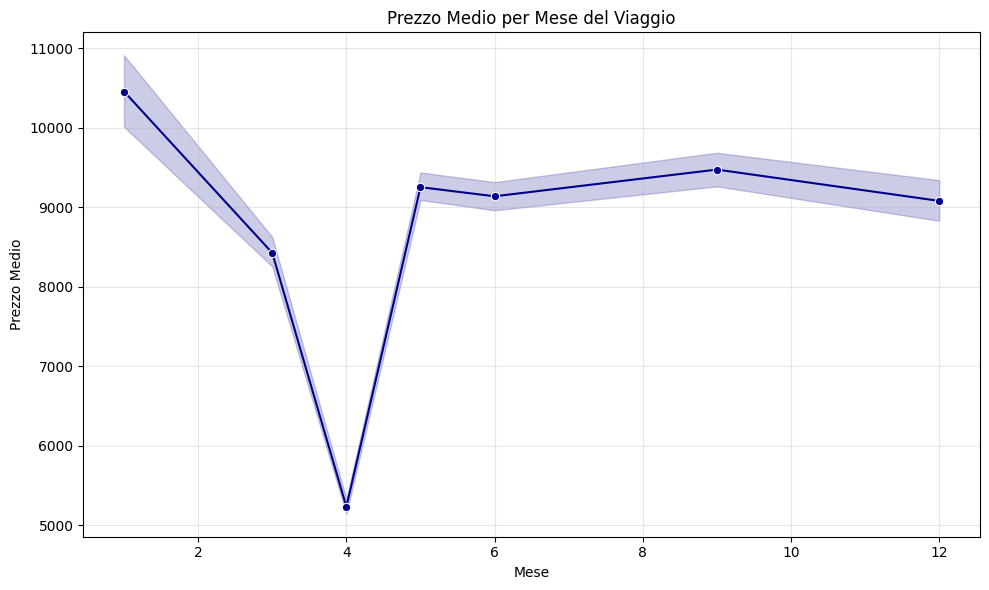

In [10]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='Journey_Month', y='Price', marker='o', color='darkblue')
plt.title('Prezzo Medio per Mese del Viaggio')
plt.xlabel('Mese')
plt.ylabel('Prezzo Medio')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/prezzi_per_mese.png')
plt.show()

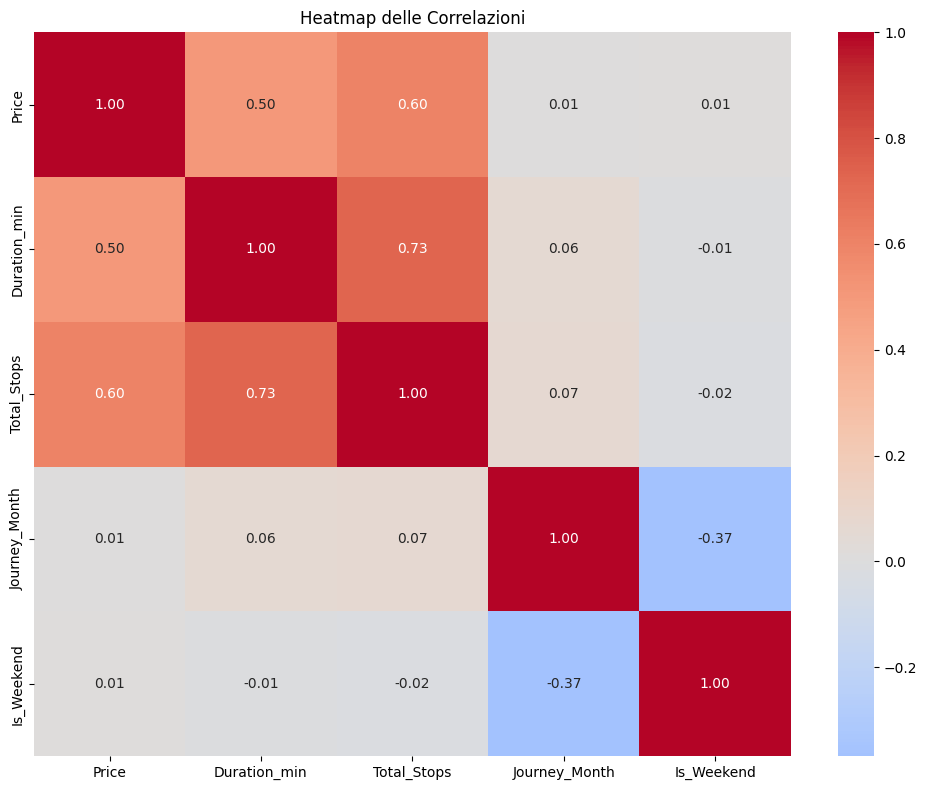

In [11]:
plt.figure(figsize=(10, 8))
corr_cols = ['Price', 'Duration_min', 'Total_Stops', 'Journey_Month', 'Is_Weekend']
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Heatmap delle Correlazioni')
plt.tight_layout()
plt.savefig('../outputs/figures/heatmap_correlazione.png')
plt.show()

C:\Users\Utente\AppData\Local\Temp\ipykernel_5340\3241149201.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Total_Stops', y='Price', palette='magma')


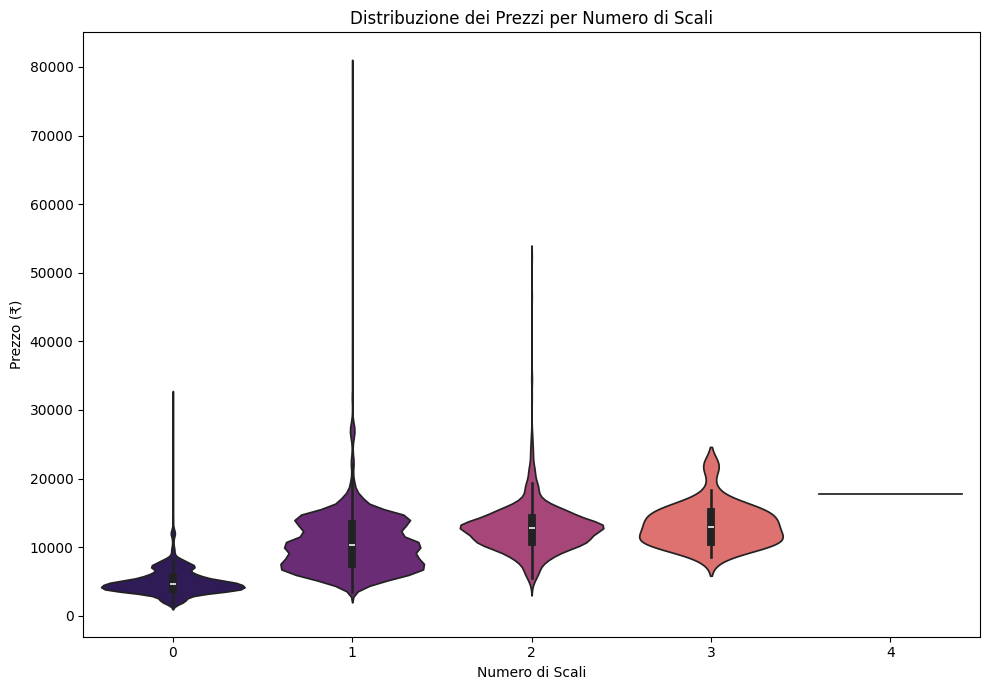

In [12]:
# 4. Violin plot prezzo vs numero di scali
plt.figure(figsize=(10, 7))
sns.violinplot(data=df, x='Total_Stops', y='Price', palette='magma')
plt.title('Distribuzione dei Prezzi per Numero di Scali')
plt.xlabel('Numero di Scali')
plt.ylabel('Prezzo (₹)')
plt.tight_layout()
plt.savefig('../outputs/figures/violin_prezzi_scali.png')
plt.show()

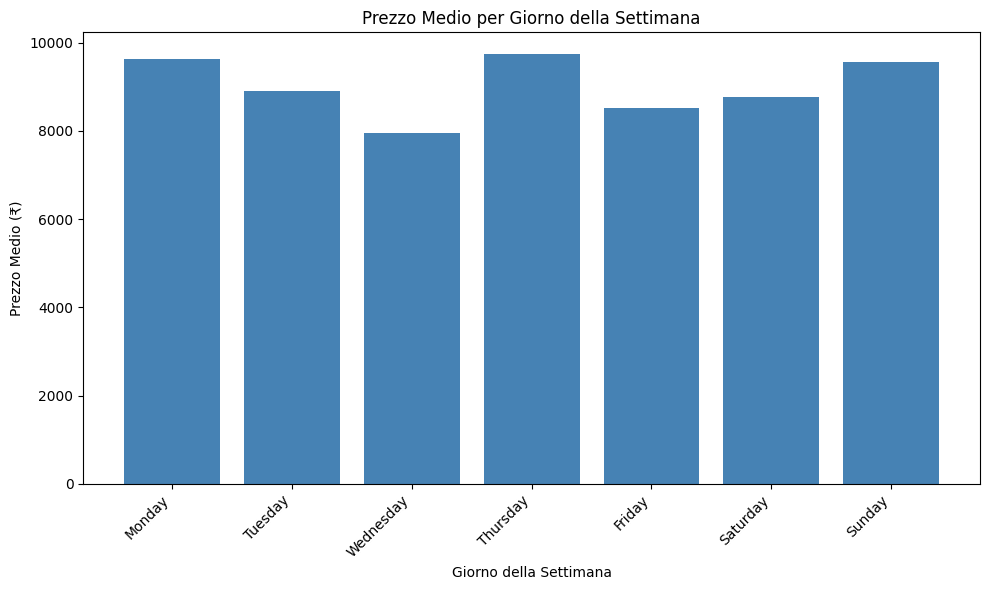

In [14]:
# 6. Andamento prezzo medio per giorno della settimana
plt.figure(figsize=(10, 6))
giorni_ordine = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
prezzo_per_giorno = df.groupby('Day_of_Week')['Price'].mean().reindex(giorni_ordine)
plt.bar(prezzo_per_giorno.index, prezzo_per_giorno.values, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title('Prezzo Medio per Giorno della Settimana')
plt.xlabel('Giorno della Settimana')
plt.ylabel('Prezzo Medio (₹)')
plt.tight_layout()
plt.savefig('../outputs/figures/prezzo_per_giorno.png')
plt.show()
